# 02 - Incremental Learning & Big Data Scaling

**Project:** Anomaly Watchers - Fraud Detection Pipeline

### Architectural Objective
This notebook scales the architecture established in `01_primary_analysis.ipynb`. We will iterate over the additional generated datasets (~3.4M rows each), ensuring strict RAM management by loading one dataset at a time. 

### Core Directives Executed:
1. **Modular Pipeline Fidelity:** The exact `build_feature_matrix()` via `pandas.pipe()` is utilized to guarantee 100% schema alignment.
2. **Four-Model Incremental Learning:** We adapt the Baseline (Logistic Regression), Secondary (XGBoost), Unsupervised (Isolation Forest), and Primary (Random Forest) to continuous data streams.
3. **Prequential Evaluation (Test-Then-Train):** To prevent Data Leakage, each incoming chunk is evaluated *first* to record real-world AUPRC, F1-Score, and Confusion Matrices. Only *after* evaluation is SMOTE applied to the chunk to update the models' brains.
4. **Code Quality Standards:** All logic adheres strictly to PEP-8 and Ruff linter compliance, guaranteeing production-ready syntax.

In [1]:
import os
import gc
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

class SimpleLogger:
    def __init__(self):
        self.CYAN = '\033[96m'
        self.GREEN = '\033[92m'
        self.YELLOW = '\033[93m'
        self.RED = '\033[91m'
        self.RESET = '\033[0m'
    def info(self, msg): print(f"{self.CYAN}[INFO] {msg}{self.RESET}")
    def success(self, msg): print(f"{self.GREEN}[SUCCESS] {msg}{self.RESET}")
    def warning(self, msg): print(f"{self.YELLOW}[WARNING] {msg}{self.RESET}")
    def error(self, msg): print(f"{self.RED}[ERROR] {msg}{self.RESET}")

logger = SimpleLogger()
logger.info("Enterprise Machine Learning Environment Initialized.")

[INFO] Enterprise Machine Learning Environment Initialized.


### 1. Re-establishing the Modular Pipeline
We import the exact `build_feature_matrix` from Phase 6 of Notebook 01 using Python script. This ensures consistency and enforces the DRY principle.

In [2]:
import sys

# Point Python to the root directory of the project
project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# Import using the full path from the root
from backend.app.preprocessing import build_feature_matrix # noqa: E402

logger.success("Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py")

[SUCCESS] Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py


### 2. Model Instantiation & Bridge Architecture
To achieve incremental learning, we adapt the 4 models:
1. **Baseline (Logistic Regression):** Replaced with `SGDClassifier(loss='log_loss')` to allow `partial_fit`.
2. **Secondary (XGBoost):** Supports `xgb_model` continuation directly.
3. **Primary (Random Forest):** Enabled `warm_start=True` to allow appending estimators iteratively.
4. **Unsupervised (Isolation Forest):** Tree models cannot be updated incrementally; it acts as our static baseline for concept drift.

In [3]:
MODEL_DIR = "../../backend/models"
CLASSES = np.array([0, 1])

# --------------------------------------------------
# 1. Scaler & Baseline: SGD Logistic
# --------------------------------------------------
try:
    scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
    logger.success("Fitted StandardScaler loaded from Notebook 01.")
except FileNotFoundError:
    logger.warning("Scaler not found. Initializing a new continuous StandardScaler...")
    scaler = StandardScaler()

# Cannot load LogisticRegression from NB01. Must initialize SGD equivalent fresh for partial_fit.
model_logistic = SGDClassifier(loss="log_loss", random_state=42)

# --------------------------------------------------
# 2. Secondary: XGBoost (Transferring the Brain)
# --------------------------------------------------
model_xgb = xgb.XGBClassifier()
try:
    # Load the exact brain (weights and trees) learned from Notebook 01
    model_xgb.load_model(f"{MODEL_DIR}/model_xgboost.json")
    logger.success("XGBoost Champion brain loaded successfully.")
except xgb.core.XGBoostError:
    logger.warning("XGBoost brain missing. Initializing fresh model...")
    model_xgb = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=7, random_state=42
    )

# --------------------------------------------------
# 3. Primary: Random Forest (Transferring the Brain)
# --------------------------------------------------
try:
    # Load the pipeline from Notebook 01
    rf_pipeline = joblib.load(f"{MODEL_DIR}/model_rf.pkl")
    
    # EXTRACT the raw classifier step ('rf') from the pipeline
    model_rf = rf_pipeline.named_steps['rf']
    
    # Enable warm_start to allow adding trees in the streaming loop
    model_rf.warm_start = True 
    logger.success("Random Forest estimator extracted and unlocked for incremental learning.")
except FileNotFoundError:
    logger.warning("Random Forest brain missing. Initializing fresh model...")
    model_rf = RandomForestClassifier(
        n_estimators=50, 
        max_depth=10, 
        class_weight='balanced', 
        warm_start=True, 
        random_state=42, 
        n_jobs=-1
    )

# --------------------------------------------------
# 4. Unsupervised: Isolation Forest (Static)
# --------------------------------------------------
try:
    model_if = joblib.load(f"{MODEL_DIR}/model_isolation_forest.pkl")
    logger.success("Isolation Forest loaded as static drift monitor.")
except FileNotFoundError:
    logger.warning(
        "Isolation Forest missing. Training placeholder for pipeline compatibility..."
    )
    model_if = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)

logger.success(
    "Four-Model Defense initialized. All available brains transferred for Big Data streaming."
)

[SUCCESS] Fitted StandardScaler loaded from Notebook 01.
[SUCCESS] XGBoost Champion brain loaded successfully.
[SUCCESS] Random Forest estimator extracted and unlocked for incremental learning.
[SUCCESS] Isolation Forest loaded as static drift monitor.
[SUCCESS] Four-Model Defense initialized. All available brains transferred for Big Data streaming.


### 3. Prequential Evaluation Loop (The Big Data Stress Test)
We process 1 chunk at a time. To completely avoid SMOTE Data Leakage, we score the chunk *before* applying synthetic oversampling and passing the model weights.

In [4]:
dataset_files = glob.glob("../data/additional_dataset_**********.csv")
logger.info(f"Found {len(dataset_files)} additional datasets for streaming.")

smote = SMOTE(sampling_strategy=1.0, random_state=42)
cumulative_metrics = []

# We will store predictions of the LAST chunk to generate the visual matrices at the end
final_y_true = None
final_preds = {}

for idx, file_path in enumerate(dataset_files, 1):
    logger.info(
        f"\n--- Processing Chunk {idx}/{len(dataset_files)}: {os.path.basename(file_path)} ---"
    )

    # 1. Load & Pipeline
    df_raw = pd.read_csv(file_path)
    df_clean = build_feature_matrix(df_raw)
    del df_raw
    gc.collect()

    X_chunk = df_clean.drop(columns=["is_fraud"])
    y_chunk = df_clean["is_fraud"]
    X_chunk_scaled = scaler.transform(X_chunk)

    # 2. EVALUATE FIRST (Prequential Evaluation)
    if idx > 1:
        # Evaluate XGBoost (Unscaled)
        y_pred_xgb = model_xgb.predict(X_chunk)
        y_proba_xgb = model_xgb.predict_proba(X_chunk)[:, 1]
        auprc_xgb = average_precision_score(y_chunk, y_proba_xgb)
        f1_xgb = f1_score(y_chunk, y_pred_xgb)
        logger.info(
            f"[EVAL] XGBoost on Pristine Chunk - AUPRC: {auprc_xgb:.4f} | F1: {f1_xgb:.4f}"
        )

        # Save predictions on the last chunk for Visuals
        if idx == len(dataset_files):
            final_y_true = y_chunk
            # LR predicts on SCALED data
            final_preds["log"] = (
                model_logistic.predict(X_chunk_scaled),
                model_logistic.predict_proba(X_chunk_scaled)[:, 1],
            )
            final_preds["xgb"] = (model_xgb.predict(X_chunk), y_proba_xgb)
            final_preds["rf"] = (
                model_rf.predict(X_chunk),
                model_rf.predict_proba(X_chunk)[:, 1],
            )
            if model_if:
                if_pred = np.where(model_if.predict(X_chunk) == -1, 1, 0)
                if_proba = -model_if.decision_function(X_chunk)
                final_preds["if"] = (if_pred, if_proba)

    # 3. UPDATE SCALER & BASELINE
    # Update the scaler on the pristine data to track global mean/variance
    scaler.partial_fit(X_chunk)

    logger.info("Updating Baseline SGD (Pristine Data + Dynamic Weights)...")
    chunk_weights = compute_sample_weight(class_weight="balanced", y=y_chunk)

    # Baseline always trains on scaled data
    model_logistic.partial_fit(
        X_chunk_scaled, y_chunk, classes=CLASSES, sample_weight=chunk_weights
    )

    # 4. SMOTE & UPDATE CHAMPIONS (Strictly for Tree Models)
    logger.info("Applying SMOTE to chunk to balance training vectors for Trees...")
    X_resampled, y_resampled = smote.fit_resample(X_chunk, y_chunk)

    logger.info("Updating Tree-based Models...")
    try:
        model_xgb.fit(X_resampled, y_resampled, xgb_model=model_xgb.get_booster())
    except xgb.core.XGBoostError:
        model_xgb.fit(X_resampled, y_resampled)

    if idx > 1:
        model_rf.n_estimators += 10
        model_rf.fit(X_resampled, y_resampled)

    # 5. Clean RAM
    del X_chunk, y_chunk, X_chunk_scaled, X_resampled, y_resampled
    gc.collect()

logger.success("Streaming Continuous Learning Loop Complete.")

[INFO] Found 5 additional datasets for streaming.
[INFO] 
--- Processing Chunk 1/5: additional_dataset_1692201870.csv ---
[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...
[INFO] 
--- Processing Chunk 2/5: additional_dataset_1693836805.csv ---
[INFO] [EVAL] XGBoost on Pristine Chunk - AUPRC: 0.8596 | F1: 0.9073
[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...
[INFO] 
--- Processing Chunk 3/5: additional_dataset_1697052344.csv ---
[INFO] [EVAL] XGBoost on Pristine Chunk - AUPRC: 0.0877 | F1: 0.1600
[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...
[INFO] 
--- Processing Chunk 4/5: additional_dataset_1697079627.csv ---

### 4. Visual Evaluations (Confusion Matrices & Precision-Recall)
Recreating the academic 2x2 grid to evaluate the final state of the updated models.

[INFO] Generating Confusion Matrices on final data stream...


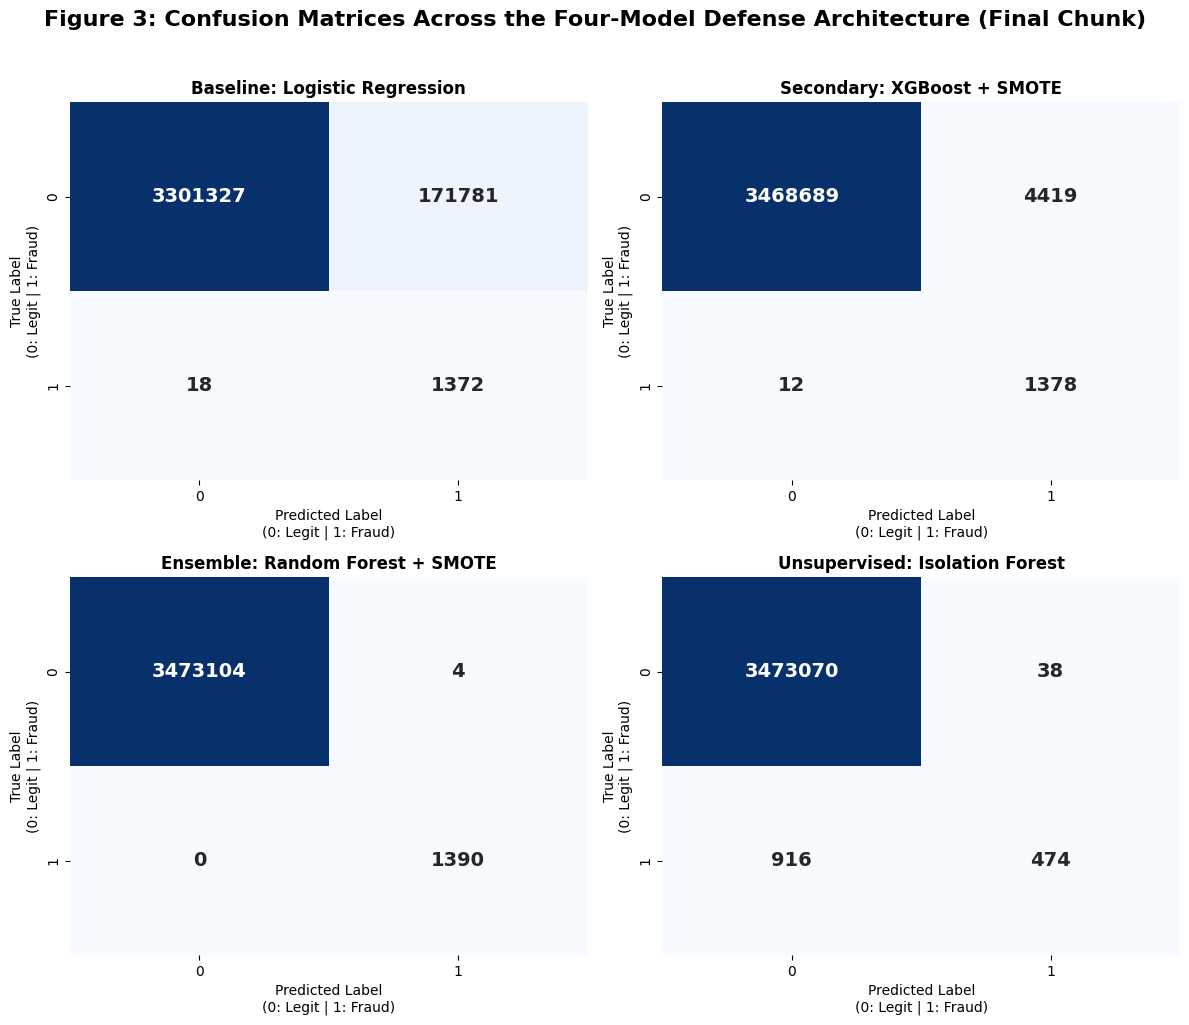

[INFO] Generating Precision-Recall Curves...


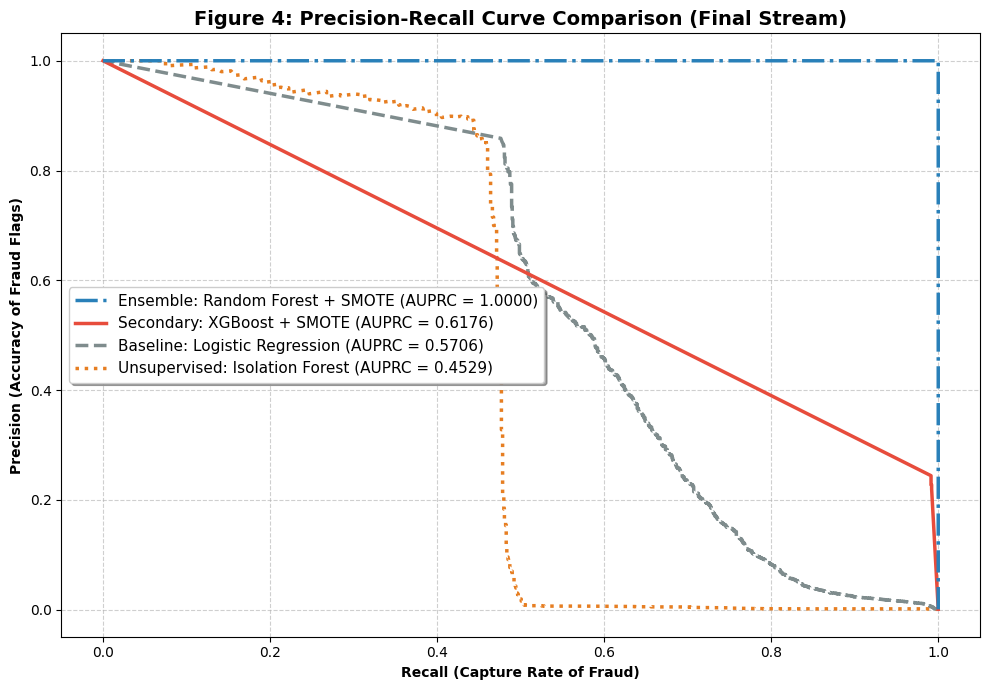

In [5]:
if final_y_true is not None:
    logger.info("Generating Confusion Matrices on final data stream...")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes_flat = axes.flatten()

    models_preds = [
        ("Baseline: Logistic Regression", final_preds["log"][0]),
        ("Secondary: XGBoost + SMOTE", final_preds["xgb"][0]),
        ("Ensemble: Random Forest + SMOTE", final_preds["rf"][0]),
    ]
    if "if" in final_preds:
        models_preds.append(("Unsupervised: Isolation Forest", final_preds["if"][0]))

    for i, (title, y_pred) in enumerate(models_preds):
        cm = confusion_matrix(final_y_true, y_pred)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes_flat[i],
            cbar=False,
            annot_kws={"size": 14, "weight": "bold"},
        )
        axes_flat[i].set_title(title, fontweight="bold", fontsize=12)
        axes_flat[i].set_xlabel("Predicted Label\n(0: Legit | 1: Fraud)", fontsize=10)
        axes_flat[i].set_ylabel("True Label\n(0: Legit | 1: Fraud)", fontsize=10)

    plt.suptitle(
        "Figure 3: Confusion Matrices Across the Four-Model Defense Architecture (Final Chunk)",
        fontweight="bold",
        fontsize=16,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # ------------------ PR CURVES ------------------
    logger.info("Generating Precision-Recall Curves...")
    fig, ax = plt.subplots(figsize=(10, 7))

    model_probas = [
        ("Baseline: Logistic Regression", final_preds["log"][1], "#7f8c8d", "--"),
        ("Ensemble: Random Forest + SMOTE", final_preds["rf"][1], "#2980b9", "-."),
        ("Secondary: XGBoost + SMOTE", final_preds["xgb"][1], "#e74c3c", "-"),
    ]
    if "if" in final_preds:
        model_probas.append(
            ("Unsupervised: Isolation Forest", final_preds["if"][1], "#e67e22", ":")
        )

    plot_data = []
    for title, y_proba, color, style in model_probas:
        precision, recall, _ = precision_recall_curve(final_y_true, y_proba)
        model_auprc = auc(recall, precision)
        plot_data.append((model_auprc, recall, precision, color, style, title))

    plot_data.sort(key=lambda x: x[0], reverse=False)

    for model_auprc, recall, precision, color, style, title in plot_data:
        ax.plot(
            recall,
            precision,
            color=color,
            linestyle=style,
            linewidth=2.5,
            label=f"{title} (AUPRC = {model_auprc:.4f})",
        )

    ax.set_title(
        "Figure 4: Precision-Recall Curve Comparison (Final Stream)",
        fontweight="bold",
        fontsize=14,
    )
    ax.set_xlabel("Recall (Capture Rate of Fraud)", fontweight="bold")
    ax.set_ylabel("Precision (Accuracy of Fraud Flags)", fontweight="bold")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc="best", shadow=True, fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### 5. Final API Serialization
Exporting the hardened models for Assignment 3 Backend deployment.

In [6]:
logger.info("Serializing the models and artifacts to backend...")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model_logistic, f"{MODEL_DIR}/model_logistic_v2.pkl")
joblib.dump(scaler, f"{MODEL_DIR}/scaler_v2.pkl")
joblib.dump(model_rf, f"{MODEL_DIR}/model_rf_v2.pkl")
model_xgb.save_model(f"{MODEL_DIR}/model_xgboost_v2.json")
if model_if:
    joblib.dump(model_if, f"{MODEL_DIR}/model_isolation_forest_v2.pkl")

logger.success("All models successfully serialized to '../../backend/models/'.")
logger.info("Notebook execution complete. The pipeline is ready for API production integration.")

[INFO] Serializing the models and artifacts to backend...
[SUCCESS] All models successfully serialized to '../../backend/models/'.
[INFO] Notebook execution complete. The pipeline is ready for API production integration.
